# A demo using Titanic (1997)
I'm picking Titanic (1997) for the demo because I assume everyone has seen it. If you haven't, what the hell are you doing with your life lol

For the purposes of the mockup, I took the liberty of downloading its script as a PDF, which I then turned into a text file. Moving forward, I would obviously use APIs to mass querry and scrape from [IMSDb](https://imsdb.com) and [SimplyScripts](https://www.simplyscripts.com).

For the sentiment analysis, I'm using the [Hedonometer](https://hedonometer.org/words/labMT-en-v2/_) from [Reagan et al. (2016)](https://link.springer.com/article/10.1140/epjds/s13688-016-0093-1), which is subject to change if I find a sentiment model that works better. You can find the Hedonometer locally under as `hedonometer.csv`.

A few basics first:

In [1]:
from pathlib import Path
import re, json, csv, subprocess
import matplotlib.pyplot as plt

# Find project root so paths work whether I run from repo root or notebooks/
here = Path.cwd()
root = None
for base in [here, here.parent]:
    if (base / 'data/lexicon/hedonometer.csv').exists():
        root = base
        break
if root is None:
    raise FileNotFoundError('data/lexicon/hedonometer.csv not found — run from repo root or notebooks/')

pdf_path = root / 'data/raw/titanic-1997.pdf'
txt_path = root / 'data/clean/titanic-1997.txt'
lex_path = root / 'data/lexicon/hedonometer.csv'
arc_path = root / 'outputs/arcs/titanic-1997.json'
fig_path = root / 'outputs/figures/titanic-1997.png'

## Loading the the Hedonometer
First, I need to load the Hedonometer, which rates words on a happiness scale from 1 to 9:

1 = extremely negative<br>
9 = extremely positive<br>
Around 5 = neutral<br>

For now, I'm using the word column and hapiness score column. (But there is also a third column that includes the standard deviation of ratings for each word.)

In [2]:
lex = {}
with lex_path.open() as f:
    reader = csv.reader(f)
    next(reader)  # header
    for row in reader:
        if len(row) < 4: continue
        word = row[1].lower()
        try: score = float(row[3])
        except ValueError: continue
        lex[word] = score

# I want to double check that the lexicon is loaded correctly (it should have 10348 entries)
len(lex)

10187

## Computing sentiment windows
A context window is the fixed chunk of text used to calculate each sentiment score as it moves through the movie script. Instead of measuring emotion line by line, it makes more sense to average sentiment across 10,000 words at a time to capture the broader patterns.

I'm choosing 10,000 words here because Reagan and his team found that smaller chunks produce unreliable sentiment results. That being said, 10,000 may be the magic number for books, but not for movie scripts. But more on that later.

Say my window is 10,000 tokens and my step is 2,000 to get a smoother arcs:

In [3]:
# First I need to tokenise the text
words = re.findall(r"[a-z']+", txt_path.read_text().lower())

# Then I set the params for how many tokens I want in each window and how much overlap I want between windows
window = 10000
step = 2000
windows = []
for i in range(0, len(words), step):
    chunk = words[i:i+window]
    if len(chunk) < window * 0.5: break
    scores = [lex[w] for w in chunk if w in lex]
    avg = sum(scores)/len(scores) if scores else None
    windows.append({
        'start': i,
        'end': i + len(chunk),
        'tokens': len(chunk),
        'coverage': len(scores)/len(chunk) if chunk else 0,
        'happiness': avg
    })
len(windows), windows[0]['happiness'] if windows else None

(20, 5.43095808383242)

So, for Titanic, 20 sentiment windows were generated. The average score Hedonometer score for the first window was 5.43095808383242, which is roughly neutral-slightly positive on the 1-9 labMT scale. I cannot tell if this makes sense yet. I need to see it first.

## Saving and plotting
I'm keeping the arc JSON and then drawing a quick line chart.

PosixPath('/Users/derinsavasan/Desktop/parsons-spring/thesis/outputs/figures/titanic-1997.png')

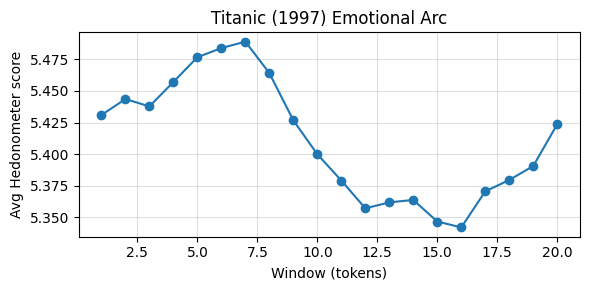

In [4]:
# Ensuring that everything exists
arc_path.parent.mkdir(parents=True, exist_ok=True)
fig_path.parent.mkdir(parents=True, exist_ok=True)

# Save the arc data as JSON for later
with arc_path.open('w') as f:
    json.dump({'window': window, 'step': step, 'windows': windows}, f, indent=2)

# Arc values and axis positions
vals = [w['happiness'] for w in windows]
xs = range(1, len(vals)+1)
plt.figure(figsize=(6,3))

# Line plot of the arc
plt.plot(xs, vals, marker='o')
plt.title('Titanic (1997) Emotional Arc')
plt.xlabel('Window (tokens)')
plt.ylabel('Avg Hedonometer score')
plt.grid(True, alpha=0.4)
plt.tight_layout()

# I want a PNG
plt.savefig(fig_path, dpi=200)

# Tell me where it's stored
fig_path

Finally, I have a visual! Shape-wise, this makes sense to me.

Jack and Rose meet >> Class barriers dissolve >> "I'm flying, Jack" >> Romantic union and personal liberation >> The iceberg >> Chaos >> Death >> Jack's sacrifice

There is a small reflective lift at the very end because the whole movie is a flashback and old Rose is remembering the memory and having the reuinion imagery. But structurally, the dominant arc is ascent followed by catastrophic fall.

So, at the macro level, Titanic is an Icarus story. Rise and fall, in that order.

## Peeking at the window stats
Just because I'm curious, I want to see the first five overlapping sentiment windows. If coverage is near 0, sentiment for that window is untrustworthy.

In [5]:
import pandas as pd
pd.DataFrame(windows)[['start','end','coverage','happiness']].head()

,start,end,coverage,happiness
0,0,10000,0.8350,5.430958
1,2000,12000,0.8473,5.443603
2,4000,14000,0.8559,5.437779
3,6000,16000,0.8643,5.457124
4,8000,18000,0.8763,5.476719


I also want to see the highest and lowest happiness scores of the arc.

In [6]:
valid_windows = [w for w in windows if w.get('happiness') is not None]

highest = max(valid_windows, key=lambda w: w['happiness'])
lowest = min(valid_windows, key=lambda w: w['happiness'])

hi_idx = windows.index(highest) + 1
lo_idx = windows.index(lowest) + 1

print(f"Highest: {highest['happiness']:.6f} (window #{hi_idx}, tokens {highest['start']}-{highest['end']}, coverage {highest['coverage']:.3f})")
print(f"Lowest : {lowest['happiness']:.6f} (window #{lo_idx}, tokens {lowest['start']}-{lowest['end']}, coverage {lowest['coverage']:.3f})")

Highest: 5.489034 (window #7, tokens 12000-22000, coverage 0.876)
Lowest : 5.342016 (window #16, tokens 30000-40000, coverage 0.858)


OK not bad.

Windows slide by 2,000 tokens but each spans 10,000 tokens, so they overlap heavily (0-10k, 2k-12k, ...). Coverage is rougly 0.83-0.88. This means that about 83-88% of tokens in each window matched a Hedonometer word, which is solid coverage. The happiness scores range from 5.43 to 5.48, which is slightly above neutral on the 1-9 labMT scale, signaling that the early parts of the script are mildly positive overall.

## Normalisation
That being said, raw scores are all clustered around 5.x, which makes the swings hard to see. If I Z-scored, it would center this script on its own mean and scales by its own std, so peaks and troughs could show how each window deviates from *this* story’s baseline.

In other words, I'm not interested in comparing Titanic to other movies yet. I just want to see the relative highs and lows within Titanic.

PosixPath('/Users/derinsavasan/Desktop/parsons-spring/thesis/outputs/figures/titanic-1997-zscore.png')

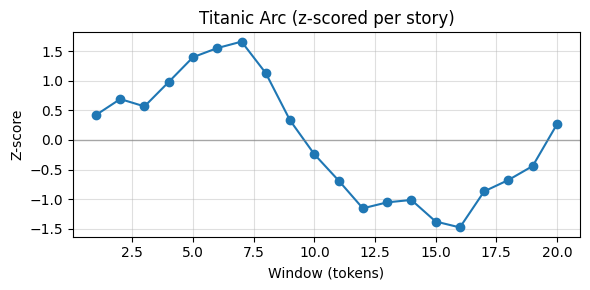

In [7]:
# Z-scoring the arc values
import numpy as np

vals = np.array([w['happiness'] for w in windows], dtype=float)
zs = (vals - vals.mean()) / vals.std()

plt.figure(figsize=(6,3))
plt.plot(range(1, len(zs)+1), zs, marker='o')
plt.axhline(0, color='gray', lw=1, alpha=0.6)
plt.title('Titanic Arc (z-scored per story)')
plt.xlabel('Window (tokens)')
plt.ylabel('Z-score')
plt.grid(True, alpha=0.4)
plt.tight_layout()

zs_fig = fig_path.with_name('titanic-1997-zscore.png')
plt.savefig(zs_fig, dpi=200)

zs_fig

Normally, I would stop here. But because this is a design mockup and I have yet to set my methodology in stone, I want to screw around more to see if I can get different shapes.

## Alternatives
At this point, I can do a few things to see more shape:

### I drop the high-SD lexicon entries
Remember when I mentioned a column on the `hedonometer.csv` and said ignore it for now? That column includes a standard deviation for each word on the Hedonometer.

If the SD for a word is high, it means people disagreed about how positive or negative that word. A good example of a high-SD word is *fucking*, because it's ambigious, context-dependent, ironic, or emotionally mixed. A low SD word like *its*, on the other hand, suggests there's a strong agreement about that word's emotional tone.

So, what if I filtered out words with high SD (e.g., SD > 2.0) to prune ambigious items without changing the scale? In other words, what if I filtered the worst offenders?


In [8]:
sd_cutoff = 1.5 # But I also tried this with 2.0
lex_filtered = {}
with lex_path.open() as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if len(row) < 5: continue
        word = row[1].lower()
        try:
            score = float(row[3])
            sd = float(row[4])
        except ValueError:
            continue
        if sd <= sd_cutoff:
            lex_filtered[word] = score

# recompute with filtered lexicon using same window/step as current run
win = window
stp = step
wins_sd = []
for i in range(0, len(words), stp):
    chunk = words[i:i+win]
    if len(chunk) < win * 0.5: break
    scores = [lex_filtered[w] for w in chunk if w in lex_filtered]
    avg = sum(scores)/len(scores) if scores else None
    wins_sd.append({
        'start': i,
        'end': i+len(chunk),
        'tokens': len(chunk),
        'coverage': len(scores)/len(chunk) if chunk else 0,
        'happiness': avg
    })
vals_sd = [w['happiness'] for w in wins_sd if w['happiness'] is not None]
cov_sd = [w['coverage'] for w in wins_sd]
print('filtered lex size', len(lex_filtered))
print('windows', len(wins_sd), 'min', min(vals_sd) if vals_sd else None, 'max', max(vals_sd) if vals_sd else None, 'cov_mean', sum(cov_sd)/len(cov_sd) if cov_sd else None)

filtered lex size 7026
windows 20 min 5.350838526144721 max 5.450132423756089 cov_mean 0.7348835761278196


My lexicon shrank quite a bit. My coverage also fell, which means many tokens no longer match the lexicon. The arc range is more compressed now, too. Clearly, the cutoff is too agressive. But then I relax the cutoff to 2.0, which barely changed anything from the original version. Perhaps that third column doesn't move the needle as much as I thought it would.

Onto the next!

### I try multiple window settings
Originally, I calculated the sentiment score using a 10,000-word window, and that window moved forward in 2,000-word steps. This means every data point reflects the emotional average of a large section of the movie's script, with substantial overlap between points. If I reduce the window size, each score would be based on a smaller chunk of text, making the emotional curve more sensitive to short-term changes instead a broad, sweeping arc.

In other words, I'm curious about the shorter-term ups and downs that happen within scenes and acts.

Here’s what I’m adding on top of the original arc (which stays as-is):
- small: 3,000-word window, 500-word step (more detail, still smooth)
- tiny: 1,500-word window, 300-word step (finest detail, most overlap)

I plot raw and z-scored arcs normalized by story progress so the shapes line up despite different window counts, and I keep coverage/min-max stats to judge reliability.


In [9]:

import pandas as pd
configs = [
    ('orig', 10000, 2000),   # baseline: coarse, overlapped
    ('small', 3000, 500),    # more detail, still smooth
    ('tiny', 1500, 300),     # finest detail, most overlap
]
results = []
series = {}  # store raw vals and z-scores for plotting later
for label, window_sz, step_sz in configs:
    wins = []
    for i in range(0, len(words), step_sz):
        chunk = words[i:i+window_sz]
        if len(chunk) < window_sz * 0.5:
            break  # skip undersized tail
        scores = [lex[w] for w in chunk if w in lex]
        avg = sum(scores)/len(scores) if scores else None
        wins.append({
            'start': i,
            'end': i+len(chunk),
            'tokens': len(chunk),
            'coverage': len(scores)/len(chunk) if chunk else 0,  # how much of window matched lexicon
            'happiness': avg,
        })
    out_json = arc_path.with_name(f"titanic-1997-{label}.json")  # save per-setting arc
    with out_json.open('w') as f:
        json.dump({'window': window_sz, 'step': step_sz, 'windows': wins}, f, indent=2)

    vals = [w['happiness'] for w in wins if w['happiness'] is not None]
    covs = [w['coverage'] for w in wins]
    if vals:
        import numpy as np
        arr = np.array(vals, dtype=float)
        zs = (arr - arr.mean()) / arr.std()  # per-setting normalization
        series[label] = {'vals': vals, 'zs': zs.tolist()}
        results.append({
            'label': label,
            'window': window_sz,
            'step': step_sz,
            'windows': len(wins),
            'happiness_min': float(arr.min()),
            'happiness_max': float(arr.max()),
            'cov_mean': sum(covs)/len(covs) if covs else None,
            'z_min': float(zs.min()),
            'z_max': float(zs.max()),
            'z_trough_idx': int(zs.argmin()),
            'z_peak_idx': int(zs.argmax()),
        })
    else:
        series[label] = {'vals': [], 'zs': []}
        results.append({
            'label': label,
            'window': window_sz,
            'step': step_sz,
            'windows': len(wins),
            'happiness_min': None,
            'happiness_max': None,
            'cov_mean': sum(covs)/len(covs) if covs else None,
            'z_min': None,
            'z_max': None,
            'z_trough_idx': None,
            'z_peak_idx': None,
        })
pd.DataFrame(results)

,label,window,step,windows,happiness_min,happiness_max,cov_mean,z_min,z_max,z_trough_idx,z_peak_idx
0,orig,10000,2000,20,5.342016,5.489034,0.860292,-1.477928,1.660891,15,6
1,small,3000,500,85,5.278272,5.525502,0.858639,-2.209134,1.790484,72,27
2,tiny,1500,300,143,5.219724,5.553452,0.858117,-2.826978,2.019421,125,50


Great, but now I want to see the difference visually.

PosixPath('/Users/derinsavasan/Desktop/parsons-spring/thesis/outputs/figures/titanic-1997-batch.png')

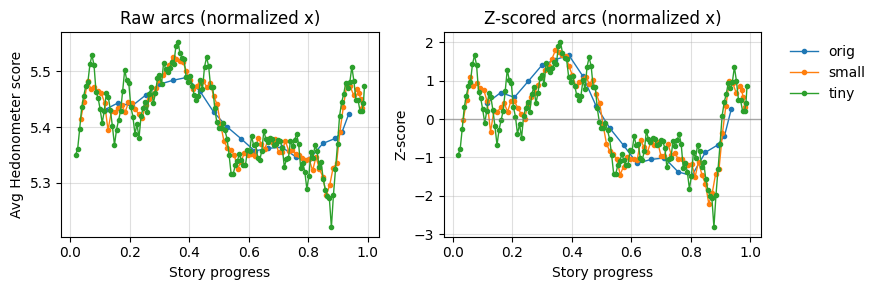

In [10]:

# Plot arcs normalized by story progress (raw and z)
# Smaller markers/lines so curves stay readable
import matplotlib.pyplot as plt
plt.figure(figsize=(9,3))

ax1 = plt.subplot(1,2,1)
for label, data in series.items():
    if not data['vals']:
        continue
    arc_json = arc_path.with_name(f"titanic-1997-{label}.json")
    arc_data = json.loads(arc_json.read_text())
    mids = [(w['start'] + w['end'])/2 for w in arc_data['windows']]   # midpoint of each window
    xs = [m/len(words) for m in mids]                                 # normalize by story length
    ax1.plot(xs, data['vals'], marker='o', markersize=3, linewidth=1, label=label)
ax1.set_title('Raw arcs (normalized x)')
ax1.set_xlabel('Story progress')
ax1.set_ylabel('Avg Hedonometer score')
ax1.grid(True, alpha=0.4)

ax2 = plt.subplot(1,2,2)
for label, data in series.items():
    if not data['zs']:
        continue
    arc_json = arc_path.with_name(f"titanic-1997-{label}.json")
    arc_data = json.loads(arc_json.read_text())
    mids = [(w['start'] + w['end'])/2 for w in arc_data['windows']]
    xs = [m/len(words) for m in mids]
    ax2.plot(xs, data['zs'], marker='o', markersize=3, linewidth=1, label=label)
ax2.axhline(0, color='gray', lw=1, alpha=0.6)                         # story baseline
ax2.set_title('Z-scored arcs (normalized x)')
ax2.set_xlabel('Story progress')
ax2.set_ylabel('Z-score')
ax2.grid(True, alpha=0.4)

plt.legend(frameon=False, bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
batch_fig = fig_path.with_name('titanic-1997-batch.png')
batch_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(batch_fig, dpi=200)
batch_fig


Even when I used smaller windows, the overall shape of the story stayed the same. The big rise, fall, and rebound still happen at the same points in the narrative.

What changes is the texture. Smaller windows make the line more jagged because they pick up shorter emotional swings within scenes. When standardized, the highs and lows still line up closely, though the smallest window shows slightly sharper dips near the end.

In short, zooming in adds detail but doesn’t change the main arc. So, I still prefer the original. Neeeeext.

### I try different sentiment models

**VADER** handles valence shifters, punctuation, and casing better than a simple word-average, or so I have been told.

I'm keeping the original window/step (10k/2k) so that I can compare directly to the very first emotional arc I drew. Scores are using VADER's compound (range -1 to 1).

Forgive me for using AI for this section. *If not for this, then for what?*

vader windows 20 min -0.9998 max 1.0
saved /Users/derinsavasan/Desktop/parsons-spring/thesis/outputs/figures/titanic-1997-vader.png
saved /Users/derinsavasan/Desktop/parsons-spring/thesis/outputs/figures/titanic-1997-vader-z.png


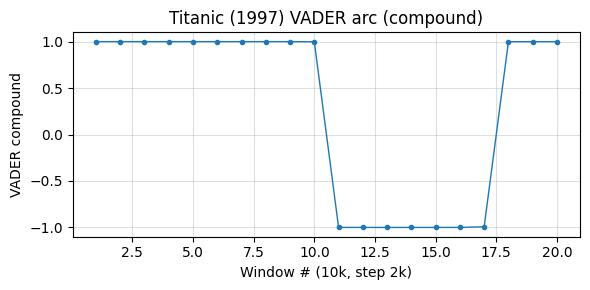

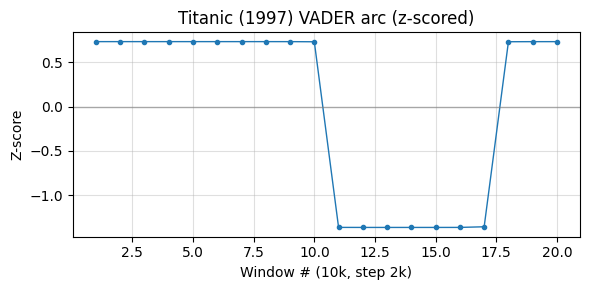

In [11]:
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    raise ImportError("Install vaderSentiment first: pip install vaderSentiment")

analyzer = SentimentIntensityAnalyzer()

vader_window = 10000
vader_step = 2000
vader_windows = []
for i in range(0, len(words), vader_step):
    chunk = words[i:i+vader_window]
    if len(chunk) < vader_window * 0.5:
        break
    text_chunk = ' '.join(chunk)
    score = analyzer.polarity_scores(text_chunk)['compound']
    vader_windows.append({
        'start': i,
        'end': i + len(chunk),
        'tokens': len(chunk),
        'compound': score
    })

# save
vader_json = arc_path.with_name('titanic-1997-vader.json')
with vader_json.open('w') as f:
    json.dump({'window': vader_window, 'step': vader_step, 'windows': vader_windows}, f, indent=2)

# stats
vals = [w['compound'] for w in vader_windows]
import numpy as np
arr = np.array(vals, dtype=float)
print('vader windows', len(vals), 'min', arr.min(), 'max', arr.max())

# plot raw + z
zs = (arr - arr.mean()) / arr.std()
xs = range(1, len(vals)+1)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(xs, vals, marker='o', markersize=3, linewidth=1)
plt.title('Titanic (1997) VADER arc (compound)')
plt.xlabel('Window # (10k, step 2k)')
plt.ylabel('VADER compound')
plt.grid(True, alpha=0.4)
vader_fig = fig_path.with_name('titanic-1997-vader.png')
vader_fig.parent.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(vader_fig, dpi=200)
print('saved', vader_fig)

# z-plot
plt.figure(figsize=(6,3))
plt.plot(xs, zs, marker='o', markersize=3, linewidth=1)
plt.axhline(0, color='gray', lw=1, alpha=0.6)
plt.title('Titanic (1997) VADER arc (z-scored)')
plt.xlabel('Window # (10k, step 2k)')
plt.ylabel('Z-score')
plt.grid(True, alpha=0.4)
vader_z_fig = fig_path.with_name('titanic-1997-vader-z.png')
plt.tight_layout()
plt.savefig(vader_z_fig, dpi=200)
print('saved', vader_z_fig)


Yikes. When I use VADER’s compound score, the arc stops looking like a gradual emotional journey and starts looking like a switch being flipped. The first half sits steadily positive, then it drops sharply into negative territory, and only at the very end does it jump back up (and rather intensely). So while the macro classification would still be Icarus (rise–fall dominant structure), the empirical shape looks like a step function, not an arc. Pass.

As a final cry for help, I'm going to throw a contextual model from **Hugging Face** into the mix. I will use `siebert/sentiment-roberta-large-english` via the HF `pipeline`. I keep the original window/step (10k/2k). Within each 10k window I split into 256-token subchunks, score each, and average signed scores (pos = +score, neg = -score).

Loading weights: 100%|██████████| 393/393 [00:04<00:00, 90.33it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]               
RobertaForSequenceClassification LOAD REPORT from: siebert/sentiment-roberta-large-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


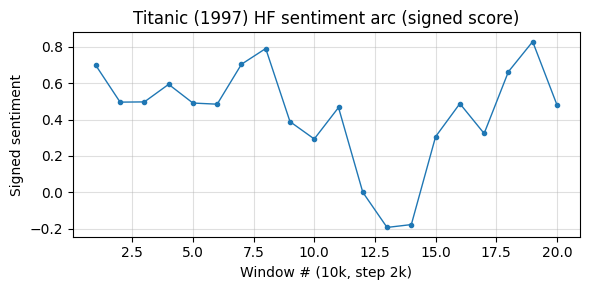

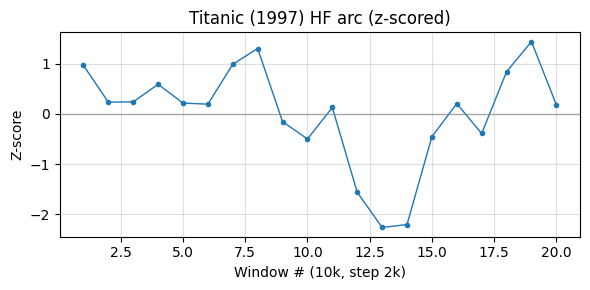

In [14]:
from pathlib import Path
import re, os, json, numpy as np, matplotlib.pyplot as plt
from transformers import pipeline

os.environ["HF_TOKEN"] = "HF_TOKEN_HERE"

root = Path("/Users/derinsavasan/Desktop/parsons-spring/thesis")  # your repo root
words = re.findall(r"[a-z']+", (root/"data/clean/titanic-1997.txt").read_text().lower())
arc_path = root/"outputs/arcs/titanic-1997.json"
fig_path = root/"outputs/figures/titanic-1997.png"

hf_window = 10_000
hf_step   = 2_000
subchunk  = 512

pipe = pipeline(
    "text-classification",
    model="siebert/sentiment-roberta-large-english",
    token=os.environ["HF_TOKEN"]
)

hf_windows = []
for i in range(0, len(words), hf_step):
    chunk = words[i:i+hf_window]
    if len(chunk) < hf_window * 0.5:
        break
    texts = [' '.join(chunk[j:j+subchunk]) for j in range(0, len(chunk), subchunk) if chunk[j:j+subchunk]]
    results = pipe(texts, truncation=True, batch_size=8)
    scores = [(r["score"] if r["label"].lower().startswith("pos") else -r["score"]) for r in results]
    hf_windows.append({
        "start": i,
        "end": i + len(chunk),
        "tokens": len(chunk),
        "coverage": len(scores)/(len(chunk)/subchunk),
        "sentiment": sum(scores)/len(scores) if scores else None,
    })

# save + plots
(root/"outputs/arcs/titanic-1997-hf.json").write_text(
    json.dumps({"window": hf_window, "step": hf_step, "windows": hf_windows}, indent=2)
)

vals = [w["sentiment"] for w in hf_windows if w["sentiment"] is not None]
arr  = np.array(vals, float)
xs   = range(1, len(vals)+1)

plt.figure(figsize=(6,3))
plt.plot(xs, vals, marker="o", markersize=3, linewidth=1)
plt.title("Titanic (1997) HF sentiment arc (signed score)")
plt.xlabel("Window # (10k, step 2k)")
plt.ylabel("Signed sentiment")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(root/"outputs/figures/titanic-1997-hf.png", dpi=200)

zs = (arr - arr.mean())/arr.std()
plt.figure(figsize=(6,3))
plt.plot(xs, zs, marker="o", markersize=3, linewidth=1)
plt.axhline(0, color="gray", lw=1, alpha=0.6)
plt.title("Titanic (1997) HF arc (z-scored)")
plt.xlabel("Window # (10k, step 2k)")
plt.ylabel("Z-score")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(root/"outputs/figures/titanic-1997-hf-z.png", dpi=200)


OK I don't mind, but I would like to see it in comparison to the other two.

### Compare Hedonometer vs. VADER vs. HF
Z-scored arcs (normalized x) for the three models, using the same 10k/2k windowing. Let's see how that looks.

PosixPath('/Users/derinsavasan/Desktop/parsons-spring/thesis/outputs/figures/titanic-1997-model-compare.png')

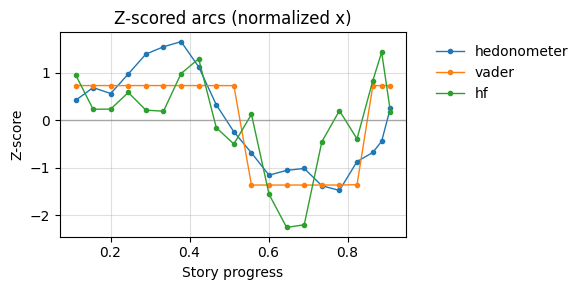

In [ ]:
# Build a z-scored comparison only (normalized x)
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

root = Path('/Users/derinsavasan/Desktop/parsons-spring/thesis')
words_len = len((root/'data/clean/titanic-1997.txt').read_text().split())

hed = json.loads((root/'outputs/arcs/titanic-1997.json').read_text())['windows']
vad = json.loads((root/'outputs/arcs/titanic-1997-vader.json').read_text())['windows']
hf  = json.loads((root/'outputs/arcs/titanic-1997-hf.json').read_text())['windows']

models = [
    ('hedonometer', [(w['start']+w['end'])/2/words_len for w in hed], [w['happiness'] for w in hed]),
    ('vader',       [(w['start']+w['end'])/2/words_len for w in vad], [w['compound'] for w in vad]),
    ('hf',          [(w['start']+w['end'])/2/words_len for w in hf],  [w['sentiment'] for w in hf]),
]

plt.figure(figsize=(6,3))
ax = plt.gca()
for label, xs, ys in models:
    arr = np.array(ys, float)
    zs = (arr - arr.mean())/arr.std()
    ax.plot(xs, zs, marker='o', markersize=3, linewidth=1, label=label)
ax.axhline(0, color='gray', lw=1, alpha=0.6)
ax.set_title('Z-scored arcs (normalized x)')
ax.set_xlabel('Story progress')
ax.set_ylabel('Z-score')
ax.grid(True, alpha=0.4)
plt.legend(frameon=False, bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
out_fig = root/'outputs/figures/titanic-1997-model-compare.png'
plt.savefig(out_fig, dpi=200)
out_fig

Yea... so while this experimentation was fun, my pick is till the Hedonometer. I like that the HF curve fluctuates more dramatically, but I'm not sure how that sensitivity would be helpful in my quest. The shape of Titanic (1997) remains stable regardless of the model.